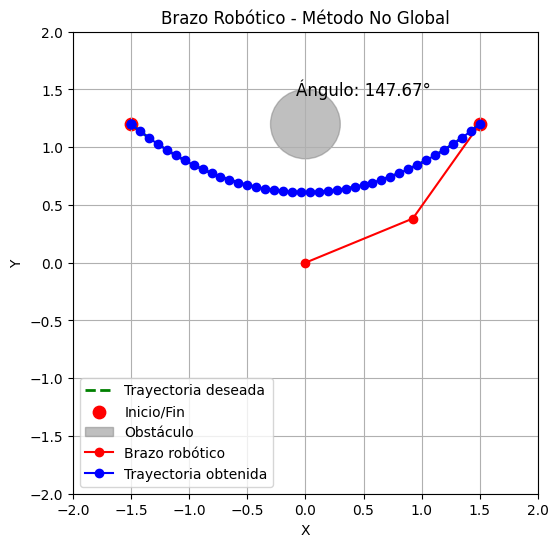

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Parámetros del brazo robótico
L1, L2 = 1.0, 1.0
T = 40

x_ini, x_fin = -1.5, 1.5
y_ini = y_fin = 1.2

obstaculo_centro = (0.0, 1.2)
obstaculo_radio = 0.3

x_deseado = np.linspace(x_ini, x_fin, T)
a = 2
x0 = 0.0
y_deseado = a * (np.cosh((x_deseado - x0) / a) - np.cosh((x_ini - x0) / a)) + 1.2

def forward_kinematics(theta1, theta2):
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    return (x1, y1), (x2, y2)

def inverse_kinematics(x, y, change_codo=False):
    r = np.sqrt(x**2 + y**2)
    cos_theta2 = (r**2 - L1**2 - L2**2) / (2 * L1 * L2)
    theta2 = np.arccos(np.clip(cos_theta2, -1, 1))
    if not change_codo:
        theta2 = -theta2
    theta1 = np.arctan2(y, x) - np.arctan2(L2 * np.sin(theta2), L1 + L2 * np.cos(theta2))
    return theta1, theta2

# Inicialización gráfica
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Brazo Robótico - Método No Global")
ax.grid(True)

ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]],
           color='red', marker='o', s=80, label="Inicio/Fin")
obstaculo = plt.Circle(obstaculo_centro, obstaculo_radio, color='gray', alpha=0.5, label="Obstáculo")
ax.add_patch(obstaculo)

brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")
angulo_texto = ax.text(0.5, 1.5, "", fontsize=12, ha='center', va='center', color='black')

# Historial de posiciones de la punta
puntas_opt = []

# Función de actualización local: calcula los ángulos justo a tiempo
def actualizar(i):
    x, y = x_deseado[i], y_deseado[i]
    change_codo = i > T // 2
    theta1, theta2 = inverse_kinematics(x, y, change_codo)
    
    codo, punta = forward_kinematics(theta1, theta2)
    brazo.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    puntas_opt.append(punta)  # Guardamos solo hasta el frame actual
    pts = np.array(puntas_opt)
    trayectoria_obtenida.set_data(pts[:, 0], pts[:, 1])
    
    angulo_grados = 180 - np.degrees(abs(theta2))
    angulo_texto.set_text(f"Ángulo: {angulo_grados:.2f}°")
    
    return brazo, trayectoria_obtenida, angulo_texto

ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
plt.legend()
HTML(ani.to_jshtml())
